# 简化 2× 退化 — 仅 Bicubic 下采样

本 Notebook 对 HR 图像仅做 **2× bicubic 下采样**，不做任何中值滤波、高斯模糊、USM 锐化。  
目的是生成**最纯净的 2× 低分辨率数据集**，配合 `lowres_2x` 的复杂退化一起做消融对比。

输出保存到 **`dataset/lowres_2x_simple/original/`**，文件名与 HR 一一对应（PNG 转 JPG 保存，质量 85）。

In [1]:
import os
import glob
import cv2
from tqdm import tqdm

hr_dir = 'dataset/highres/original'
lr_dir = 'dataset/lowres_2x_simple/original'
scale = 2

os.makedirs(lr_dir, exist_ok=True)

hr_image_paths = sorted(glob.glob(os.path.join(hr_dir, '*.[jp][pn]*g')))
print(f"HR 图片总数: {len(hr_image_paths)}")

HR 图片总数: 1481


In [2]:
saved_count = 0

for hr_path in tqdm(hr_image_paths, desc='2x bicubic downsample'):
    img_hr = cv2.imread(hr_path)
    if img_hr is None:
        print(f"无法读取: {hr_path}")
        continue

    h, w = img_hr.shape[:2]
    lr_h, lr_w = h // scale, w // scale
    img_lr = cv2.resize(img_hr, (lr_w, lr_h), interpolation=cv2.INTER_CUBIC)

    filename = os.path.basename(hr_path)
    if filename.lower().endswith('.png'):
        filename = filename[:-4] + '.jpg'
    lr_path = os.path.join(lr_dir, filename)

    cv2.imwrite(lr_path, img_lr, [int(cv2.IMWRITE_JPEG_QUALITY), 85])
    saved_count += 1

print(f"\n完成: {saved_count}/{len(hr_image_paths)} 张 LR 图片已保存到 {lr_dir}")

2x bicubic downsample: 100%|██████████| 1481/1481 [04:00<00:00,  6.15it/s]


完成: 1481/1481 张 LR 图片已保存到 dataset/lowres_2x_simple/original


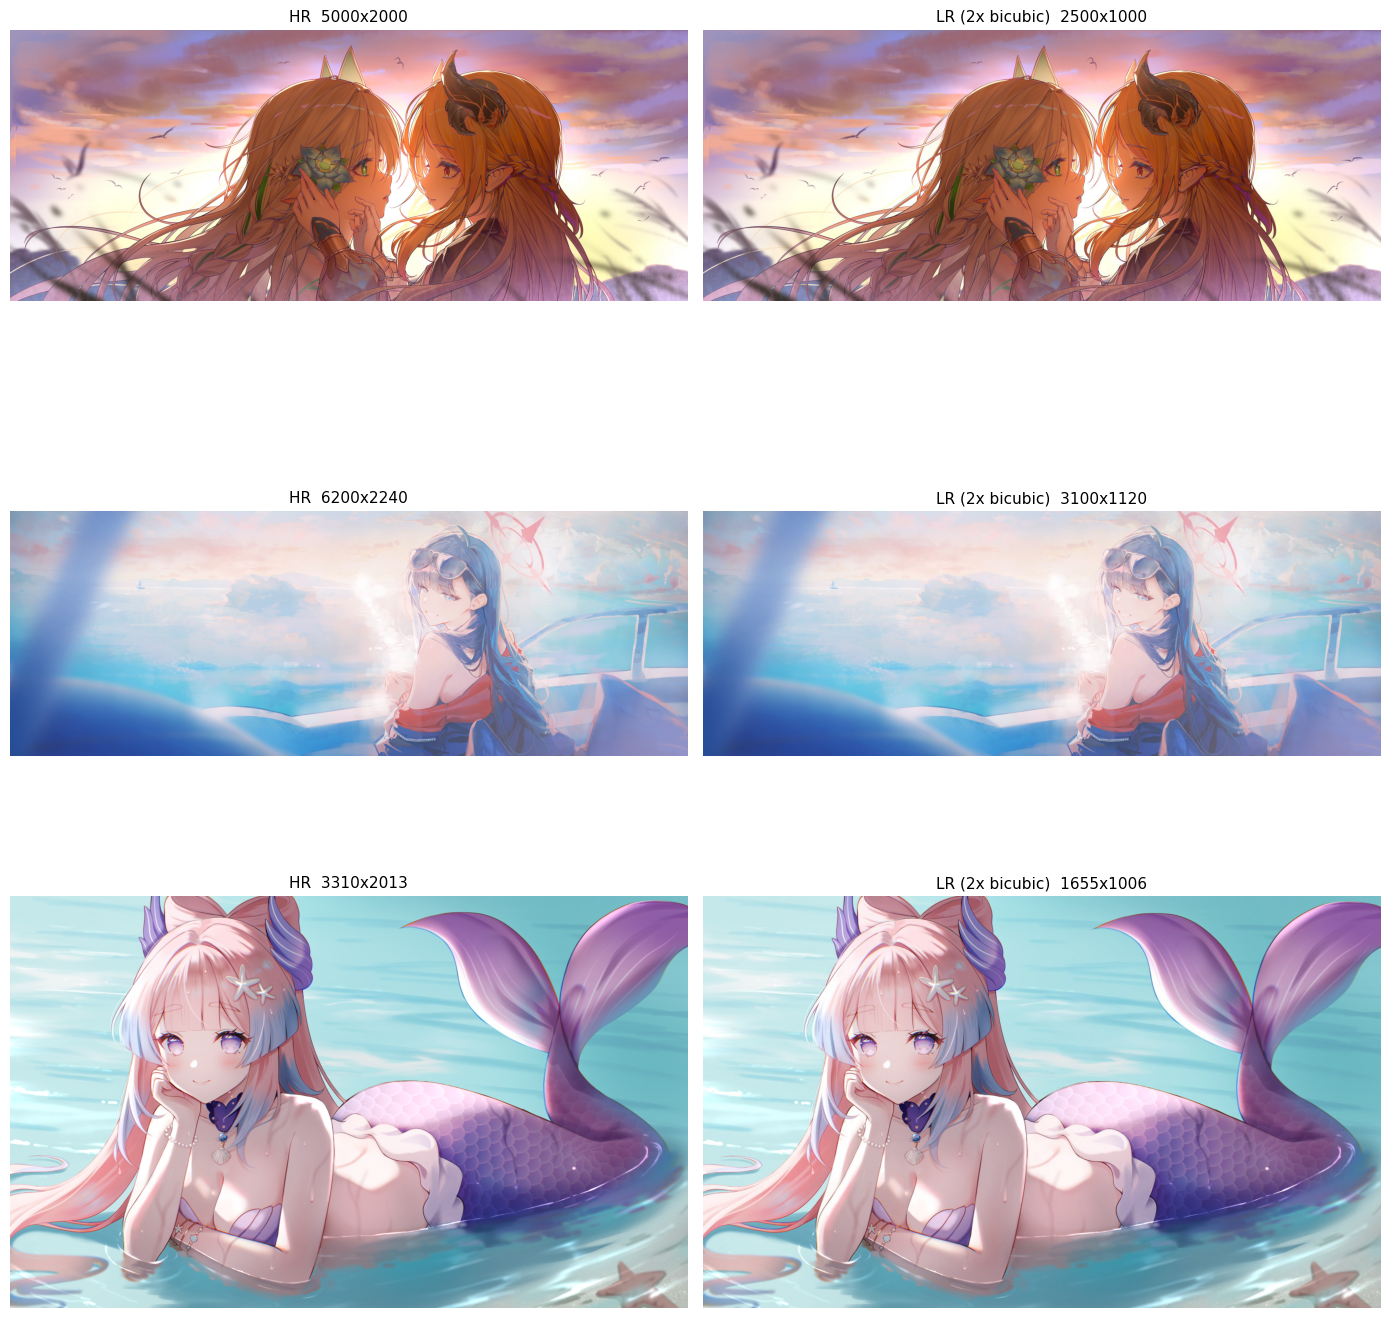

In [3]:
import matplotlib.pyplot as plt
import random

sample_paths = random.sample(hr_image_paths, min(3, len(hr_image_paths)))

fig, axes = plt.subplots(len(sample_paths), 2, figsize=(14, 5 * len(sample_paths)))
if len(sample_paths) == 1:
    axes = [axes]

for i, hr_path in enumerate(sample_paths):
    filename = os.path.basename(hr_path)
    if filename.lower().endswith('.png'):
        filename = filename[:-4] + '.jpg'
    lr_path = os.path.join(lr_dir, filename)

    hr_img = cv2.cvtColor(cv2.imread(hr_path), cv2.COLOR_BGR2RGB)
    lr_img = cv2.cvtColor(cv2.imread(lr_path), cv2.COLOR_BGR2RGB)

    axes[i][0].imshow(hr_img)
    axes[i][0].set_title(f'HR  {hr_img.shape[1]}x{hr_img.shape[0]}', fontsize=11)
    axes[i][0].axis('off')

    axes[i][1].imshow(lr_img)
    axes[i][1].set_title(f'LR (2x bicubic)  {lr_img.shape[1]}x{lr_img.shape[0]}', fontsize=11)
    axes[i][1].axis('off')

plt.tight_layout()
plt.show()